# Exploratory Data Analysis (EDA)

SCB Cooperative Internship Take-Home Test: Fraudulent Transaction Detection

by Sawit Koseeyaumporn

In [1]:
!hf download celesca/fraud --repo-type dataset --local-dir ./

Fetching 3 files:   0% 0/3 [00:00<?, ?it/s]Downloading '.gitattributes' to '.cache/huggingface/download/wPaCkH-WbT7GsmxMKKrNZTV4nSM=.1ef325f1b111266a6b26e0196871bd78baa8c2f3.incomplete'

.gitattributes: 2.46kB [00:00, 1.05MB/s]
Download complete. Moving file to .gitattributes
Fetching 3 files:  33% 1/3 [00:00<00:00,  2.27it/s]
README.md: 100% 31.0/31.0 [00:00<00:00, 293kB/s]
Download complete. Moving file to README.md

download.zip:   0% 0.00/170M [00:00<?, ?B/s]
download.zip:  39% 67.0M/170M [00:02<00:03, 31.6MB/s]
download.zip:  79% 134M/170M [00:02<00:00, 60.1MB/s] 
download.zip: 100% 170M/170M [00:03<00:00, 56.6MB/s]
Download complete. Moving file to download.zip
Fetching 3 files: 100% 3/3 [00:03<00:00,  1.23s/it]
/content


In [2]:
!unzip download.zip

Archive:  download.zip
  inflating: fraud_mock.csv          


In [3]:
import pandas as pd

df = pd.read_csv("fraud_mock.csv")

### 1. Missing values and data understanding

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6362620 entries, 0 to 6362619
Data columns (total 11 columns):
 #   Column            Dtype  
---  ------            -----  
 0   time_ind          int64  
 1   transac_type      object 
 2   amount            float64
 3   src_acc           object 
 4   src_bal           float64
 5   src_new_bal       float64
 6   dst_acc           object 
 7   dst_bal           float64
 8   dst_new_bal       float64
 9   is_fraud          int64  
 10  is_flagged_fraud  int64  
dtypes: float64(5), int64(3), object(3)
memory usage: 534.0+ MB


In [ ]:
display(df.head())
display(df.isnull().sum())

,time_ind,transac_type,amount,src_acc,src_bal,src_new_bal,dst_acc,dst_bal,dst_new_bal,is_fraud,is_flagged_fraud
0,1,PAYMENT,9839.64,acc910286,170136.0,160296.36,acc298089,0.0,0.0,0,0
1,1,PAYMENT,1864.28,acc6597009,21249.0,19384.72,acc8726693,0.0,0.0,0,0
2,1,TRANSFER,181.00,acc1796908,181.0,0.00,acc4938640,0.0,0.0,1,0
3,1,CASH_OUT,181.00,acc4182296,181.0,0.00,acc1221153,21182.0,0.0,1,0
4,1,PAYMENT,11668.14,acc7841596,41554.0,29885.86,acc5599142,0.0,0.0,0,0


,0
time_ind,0
transac_type,0
amount,0
src_acc,0
src_bal,0
src_new_bal,0
dst_acc,0
dst_bal,0
dst_new_bal,0
is_fraud,0


* We can see that the data has no missing values.

### 2. Check imbalance datasets (on target `is_fraud`)

In [6]:
df['is_fraud'].value_counts()

,count
is_fraud,
0,6354407
1,8213


In [7]:
df['is_fraud'].value_counts(normalize=True) * 100

,proportion
is_fraud,
0,99.870918
1,0.129082


* Very imbalanced datasets

not fraud - 99.87%
is fraud - 0.129%

That's mean if we want to did the classification model it should be handles with undersampling or SMOTE techniques.

### 3. Explore the transaction types and their relationship with fraud.

In [8]:
df['transac_type'].value_counts()

,count
transac_type,
CASH_OUT,2237500
PAYMENT,2151495
CASH_IN,1399284
TRANSFER,532909
DEBIT,41432


In [9]:
# Value counts of is_fraud

df[df['is_fraud'] == 1]['transac_type'].value_counts()

,count
transac_type,
CASH_OUT,4116
TRANSFER,4097


In [10]:
# Value counts of is not fraud

df[df['is_fraud'] == 0]['transac_type'].value_counts()

,count
transac_type,
CASH_OUT,2233384
PAYMENT,2151495
CASH_IN,1399284
TRANSFER,528812
DEBIT,41432


### **Key Insight** : The fraud transactions have transaction type only `CASH_OUT` and `TRANSFER`

### 4. Explore the transaction amounts and their relationship with fraud.

In [18]:
# Fraud amount
df[df['is_fraud'] == 1]['amount'].describe()

,amount
count,8.213000e+03
mean,1.467967e+06
std,2.404253e+06
min,0.000000e+00
25%,1.270913e+05
50%,4.414234e+05
75%,1.517771e+06
max,1.000000e+07


In [17]:
# Non fraud amount
df[df['is_fraud'] == 0]['amount'].describe()

,amount
count,6.354407e+06
mean,1.781970e+05
std,5.962370e+05
min,1.000000e-02
25%,1.336840e+04
50%,7.468472e+04
75%,2.083648e+05
max,9.244552e+07


* Visualize the amount for fraud and non-fraud transactions, using log scale for skewed data

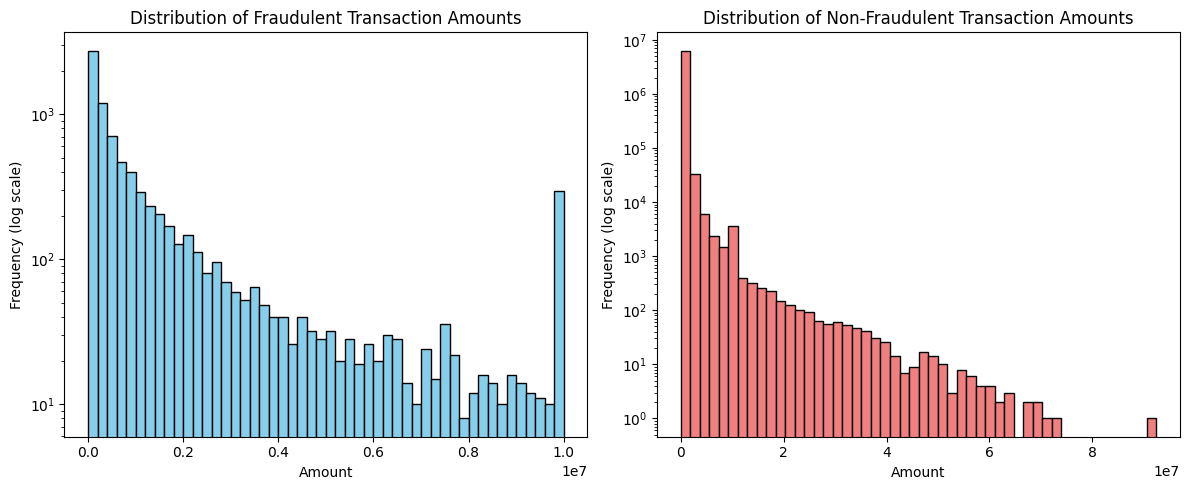

In [19]:
import matplotlib.pyplot as plt
import numpy as np

fraudulent_amounts = df[df['is_fraud'] == 1]['amount']
non_fraudulent_amounts = df[df['is_fraud'] == 0]['amount']

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].hist(fraudulent_amounts, bins=50, color='skyblue', edgecolor='black', log=True)
axes[0].set_title('Distribution of Fraudulent Transaction Amounts')
axes[0].set_xlabel('Amount')
axes[0].set_ylabel('Frequency (log scale)')

axes[1].hist(non_fraudulent_amounts, bins=50, color='lightcoral', edgecolor='black', log=True)
axes[1].set_title('Distribution of Non-Fraudulent Transaction Amounts')
axes[1].set_xlabel('Amount')
axes[1].set_ylabel('Frequency (log scale)')

plt.tight_layout()
plt.show()

### 5. Explore distribution of account balances (`src_bal`, `src_new_bal`, `dst_bal`, `dst_new_bal`) and their relationship with fraud.


In [ ]:
df_fraudulent = df[df['is_fraud'] == 1]
df_non_fraudulent = df[df['is_fraud'] == 0]

balance_cols = ['src_bal', 'src_new_bal', 'dst_bal', 'dst_new_bal']

print("Descriptive statistics for balance columns (Fraudulent Transactions):")
display(df_fraudulent[balance_cols].describe())

print("\nDescriptive statistics for balance columns (Non-Fraudulent Transactions):")
display(df_non_fraudulent[balance_cols].describe())

Descriptive statistics for balance columns (Fraudulent Transactions):


,src_bal,src_new_bal,dst_bal,dst_new_bal
count,8.213000e+03,8.213000e+03,8.213000e+03,8.213000e+03
mean,1.649668e+06,1.923926e+05,5.442496e+05,1.279708e+06
std,3.547719e+06,1.965666e+06,3.336421e+06,3.908817e+06
min,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,1.258224e+05,0.000000e+00,0.000000e+00,0.000000e+00
50%,4.389835e+05,0.000000e+00,0.000000e+00,4.676420e+03
75%,1.517771e+06,0.000000e+00,1.478287e+05,1.058725e+06
max,5.958504e+07,4.958504e+07,2.362305e+08,2.367265e+08



Descriptive statistics for balance columns (Non-Fraudulent Transactions):


,src_bal,src_new_bal,dst_bal,dst_new_bal
count,6.354407e+06,6.354407e+06,6.354407e+06,6.354407e+06
mean,8.328287e+05,8.559702e+05,1.101421e+06,1.224926e+06
std,2.887144e+06,2.924987e+06,3.399202e+06,3.673816e+06
min,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
50%,1.406900e+04,0.000000e+00,1.333118e+05,2.148817e+05
75%,1.069695e+05,1.447307e+05,9.441446e+05,1.111975e+06
max,4.381886e+07,4.368662e+07,3.560159e+08,3.561793e+08


Visualize Histogram of distribution of the balance columns for both fraudulent and non-fraudulent transactions



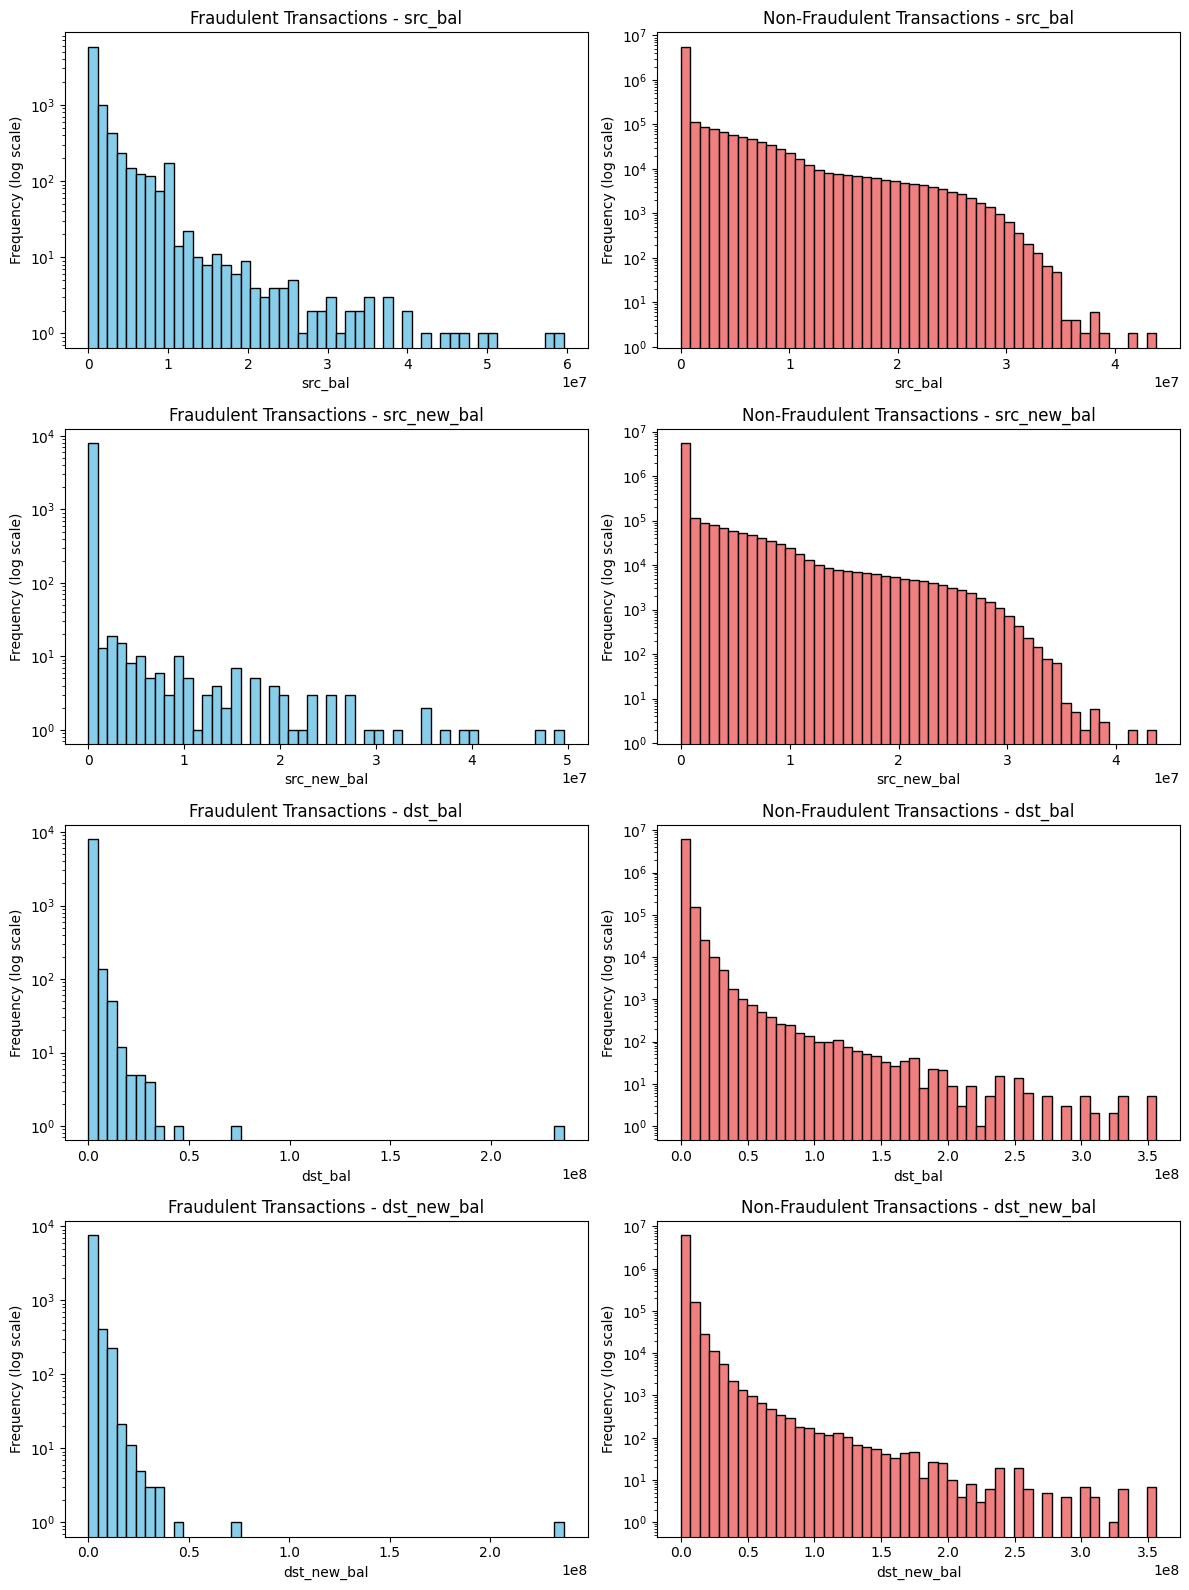

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

balance_cols = ['src_bal', 'src_new_bal', 'dst_bal', 'dst_new_bal']

fig, axes = plt.subplots(len(balance_cols), 2, figsize=(12, 16))
axes = axes.flatten()

for i, col in enumerate(balance_cols):
    axes[2*i].hist(df_fraudulent[col].replace([np.inf, -np.inf], np.nan).dropna(), bins=50, color='skyblue', edgecolor='black', log=True)
    axes[2*i].set_title(f'Fraudulent Transactions - {col}')
    axes[2*i].set_xlabel(col)
    axes[2*i].set_ylabel('Frequency (log scale)')

    axes[2*i+1].hist(df_non_fraudulent[col].replace([np.inf, -np.inf], np.nan).dropna(), bins=50, color='lightcoral', edgecolor='black', log=True)
    axes[2*i+1].set_title(f'Non-Fraudulent Transactions - {col}')
    axes[2*i+1].set_xlabel(col)
    axes[2*i+1].set_ylabel('Frequency (log scale)')

plt.tight_layout()
plt.show()

### **Key Insight** : จากการสำรวจเราจะสังเกตว่า Distribution ของกราฟที่เป็น Fraud จะมีการกระจายตัวที่กระจุกตัวอยู่ทางด้านซ้ายและไม่กระจายตัวเหมือนกับ Non-fraud ทั้งใน src_new_bal, dst_bal, dst_new_bal

### 6. Explore time trends - for my curious if we can use the time series to did the AI model

If applicable, analyze how fraud varies over time using the `time_ind` column.


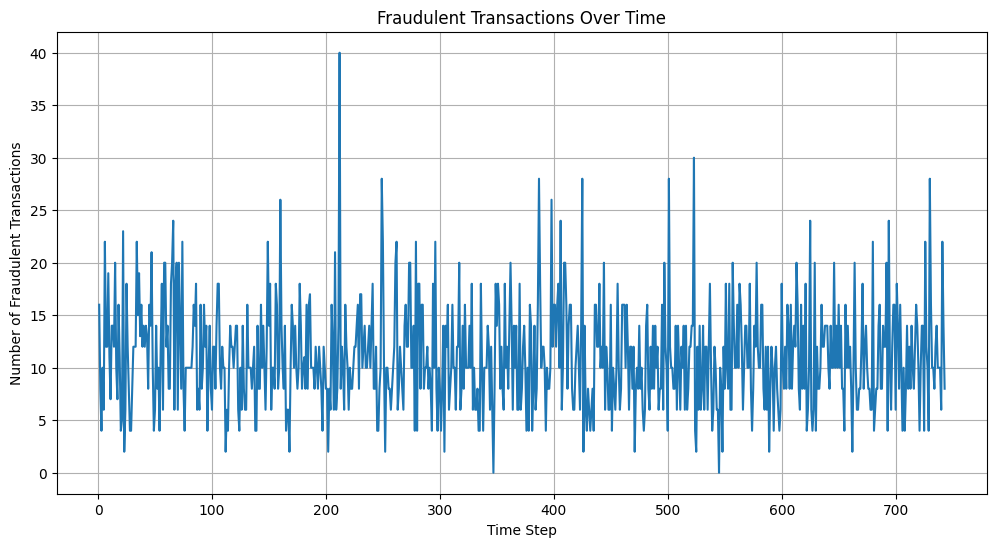

In [ ]:
import matplotlib.pyplot as plt

fraud_over_time = df.groupby('time_ind')['is_fraud'].sum()

plt.figure(figsize=(12, 6))
plt.plot(fraud_over_time.index, fraud_over_time.values)
plt.xlabel('Time Step')
plt.ylabel('Number of Fraudulent Transactions')
plt.title('Fraudulent Transactions Over Time')
plt.grid(True)
plt.show()

Time Trends in Fraud:
- Analysis of fraudulent transactions over time ('time_ind') revealed variations in the number of fraudulent activities across different time steps.
- The plot of fraud over time shows fluctuations, but no clear increasing or decreasing trend was immediately apparent.
- Further time-series analysis could potentially reveal more granular temporal patterns.

### 7. Flagged Fraud - Transactions flagged for illegal attempts (e.g. transferring more than 200,000 in one transaction)

In [26]:
df[df["is_flagged_fraud"] == 1]

,time_ind,transac_type,amount,src_acc,src_bal,src_new_bal,dst_acc,dst_bal,dst_new_bal,is_fraud,is_flagged_fraud
2736446,212,TRANSFER,4953893.08,acc2680695,4953893.08,4953893.08,acc8084602,0.0,0.0,1,1
3247297,250,TRANSFER,1343002.08,acc8152455,1343002.08,1343002.08,acc6721727,0.0,0.0,1,1
3760288,279,TRANSFER,536624.41,acc5456401,536624.41,536624.41,acc2588125,0.0,0.0,1,1
5563713,387,TRANSFER,4892193.09,acc2836279,4892193.09,4892193.09,acc324927,0.0,0.0,1,1
5996407,425,TRANSFER,10000000.00,acc6473400,19585040.37,19585040.37,acc1171375,0.0,0.0,1,1
5996409,425,TRANSFER,9585040.37,acc4711553,19585040.37,19585040.37,acc6868459,0.0,0.0,1,1
6168499,554,TRANSFER,3576297.10,acc1023994,3576297.10,3576297.10,acc1064142,0.0,0.0,1,1
6205439,586,TRANSFER,353874.22,acc1149097,353874.22,353874.22,acc1427736,0.0,0.0,1,1
6266413,617,TRANSFER,2542664.27,acc3456763,2542664.27,2542664.27,acc4965290,0.0,0.0,1,1
6281482,646,TRANSFER,10000000.00,acc191137,10399045.08,10399045.08,acc1496862,0.0,0.0,1,1


* the is_fraud will always be with is_flagged_fraud

### 8. Explore relationships between features


Calculate the correlation matrix for numerical columns and visualize it using a heatmap to understand relationships between numerical features and the target variable.



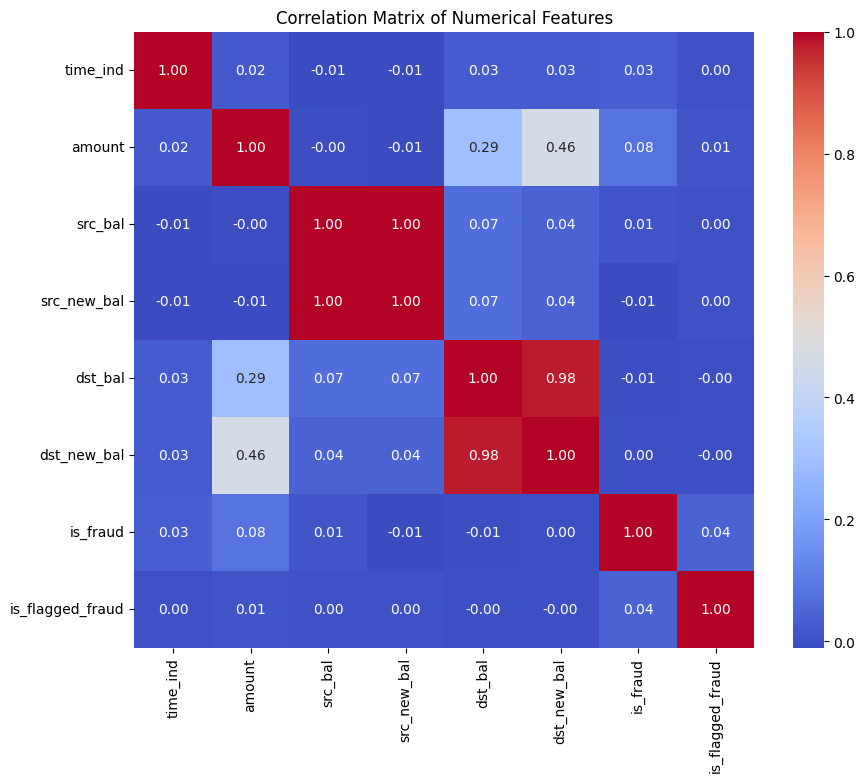

In [27]:
import seaborn as sns

numerical_cols = df.select_dtypes(include=['float64', 'int64']).columns
correlation_matrix = df[numerical_cols].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix of Numerical Features')
plt.show()

* The correlation matrix showed weak linear correlations between most numerical features and 'is_fraud'.

* 'amount' and 'is_flagged_fraud' had the highest (though still low) positive correlations with 'is_fraud'.

* This suggests that while linear relationships are weak, non-linear relationships or interactions between features might be important.

Then, group the DataFrame by transaction type and calculate the mean of 'is_fraud' to assess the relationship between transaction type and fraud. Finally, examine the amount distribution specifically for fraudulent 'TRANSFER' and 'CASH_OUT' transactions.

In [29]:
fraud_by_transaction_type = df.groupby('transac_type')['is_fraud'].mean().sort_values(ascending=False)
display(fraud_by_transaction_type)

,is_fraud
transac_type,
TRANSFER,0.007688
CASH_OUT,0.001840
CASH_IN,0.000000
DEBIT,0.000000
PAYMENT,0.000000


In [30]:
fraudulent_transfer_amounts = df[(df['is_fraud'] == 1) & (df['transac_type'] == 'TRANSFER')]['amount']
fraudulent_cash_out_amounts = df[(df['is_fraud'] == 1) & (df['transac_type'] == 'CASH_OUT')]['amount']

print("\nDescriptive statistics for fraudulent TRANSFER amounts:")
display(fraudulent_transfer_amounts.describe())

print("\nDescriptive statistics for fraudulent CASH_OUT amounts:")
display(fraudulent_cash_out_amounts.describe())


Descriptive statistics for fraudulent TRANSFER amounts:


,amount
count,4.097000e+03
mean,1.480892e+06
std,2.414890e+06
min,6.380000e+01
25%,1.284180e+05
50%,4.457058e+05
75%,1.534985e+06
max,1.000000e+07



Descriptive statistics for fraudulent CASH_OUT amounts:


,amount
count,4.116000e+03
mean,1.455103e+06
std,2.393842e+06
min,0.000000e+00
25%,1.254645e+05
50%,4.355169e+05
75%,1.500761e+06
max,1.000000e+07


---

### 9. (Optional) Try Clustering approaches

My idea of this approaches is to check the algorithms from the clustering to see if we can classify it with the clustering with the UMAP (n=2)

/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


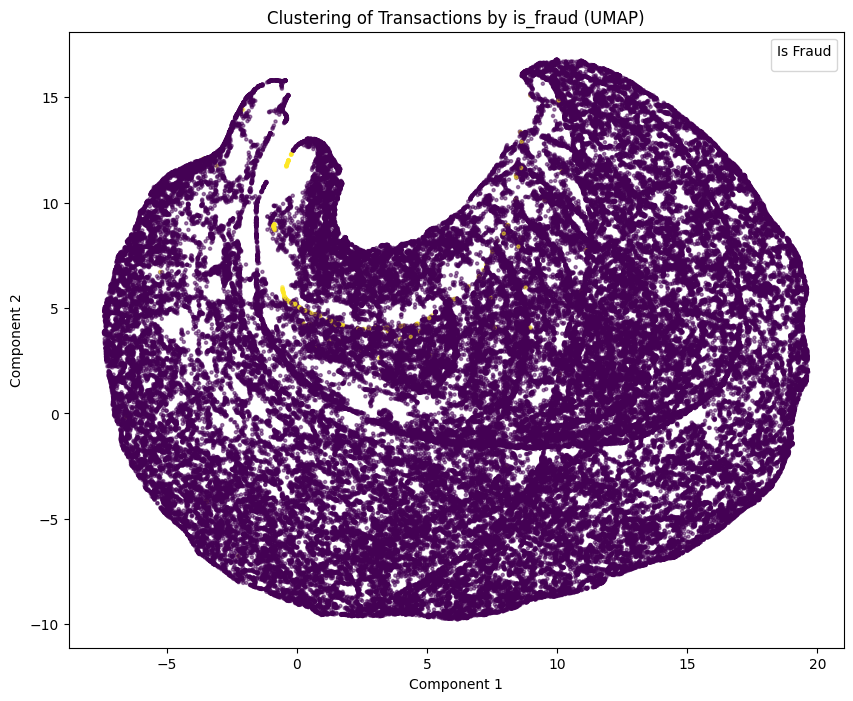

In [9]:
import pandas as pd
from umap import UMAP
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler

df = pd.read_csv("fraud_mock.csv")

df_filtered = df[df['transac_type'].isin(['TRANSFER', 'CASH_OUT'])].copy()

# Take a sample of the filtered data
sample_size = 100000
if len(df_filtered) > sample_size:
    df_sampled = df_filtered.sample(sample_size, random_state=42)
else:
    df_sampled = df_filtered

X_numerical = df_sampled[['amount', 'src_bal', 'src_new_bal', 'dst_bal', 'dst_new_bal']]
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_numerical)
y_filtered = df_sampled['is_fraud']

umap_reducer = UMAP(n_components=2, random_state=42)
X_reduced = umap_reducer.fit_transform(X_scaled)

plt.figure(figsize=(10, 8))
scatter = plt.scatter(X_reduced[:, 0], X_reduced[:, 1], c=y_filtered, cmap='viridis', s=5, alpha=0.5)
plt.title('Clustering of Transactions by is_fraud (UMAP)')
plt.xlabel('Component 1')
plt.ylabel('Component 2')
legend_labels = {0: 'Non-Fraud', 1: 'Fraud'}
handles, labels = scatter.legend_elements(prop="colors")
valid_handles = [h for h, label in zip(handles, labels) if label.split('_')[-1].isdigit()]
valid_labels = [label for label in labels if label.split('_')[-1].isdigit()]
legend = plt.legend(valid_handles, [legend_labels[int(label.split('_')[-1])] for label in valid_labels], title="Is Fraud")
plt.show()

From the UMAP clustering we can see that the data is quite hard to use this approaches to classify. So there's no insights from this clustering

---

# Key Insights from EDA

1. Dataset Characteristics and Class Imbalance:
- The dataset contains 6362620 transactions with 11 features.
- There are no missing values in the dataset.
- The target variable 'is_fraud' shows a significant class imbalance:
  - Non-fraudulent transactions (0): 6354407 (99.87%)
  - Fraudulent transactions (1): 8213 (0.13%)
- This severe imbalance (only 0.13% fraudulent transactions) is a critical factor for model development and evaluation.

2. Transaction Type and Fraud:
- Fraudulent transactions are concentrated exclusively in 'TRANSFER' and 'CASH_OUT' transaction types.
- 'TRANSFER' has the highest fraud rate (0.0077), followed by 'CASH_OUT' (0.0018).
- 'PAYMENT', 'CASH_IN', and 'DEBIT' transaction types show no instances of fraud in this dataset.
- This suggests that transaction type is a highly informative feature for identifying potential fraud.
- **That's mean** we can use the rules to classify the non-fraud at first.

3. Transaction Amount and Fraud:
- Fraudulent transactions generally involve higher amounts compared to non-fraudulent ones.
- Descriptive statistics show higher mean and median amounts for fraudulent transactions.
- While fraudulent amounts can be large (up to 10000000.00), the absolute largest transactions in the dataset are non-fraudulent.
- The distribution of fraudulent amounts is skewed towards higher values within the 'TRANSFER' and 'CASH_OUT' categories.

4. Account Balances and Fraud:
- Differences were observed in account balances between fraudulent and non-fraudulent transactions.
- Fraudulent transactions tend to have higher initial and new balances for both source and destination accounts on average, although with high variability.
- Visualizations highlighted distinct distribution patterns for balances, with non-fraudulent transactions having a larger concentration at zero or low balances.
- Account balances, particularly the changes in balances, appear to be relevant features for fraud detection.

5. Relationships with Other Features:
- The correlation matrix showed weak linear correlations between most numerical features and 'is_fraud'.
- 'amount' and 'is_flagged_fraud' had the highest (though still low) positive correlations with 'is_fraud'.
- **This suggests** that while linear relationships are weak, non-linear relationships or interactions between features might be important.

6. Overall Assessment of Informative Features:
- Based on the EDA, the most informative features for fraud detection appear to be:
  - `transac_type`: Highly discriminative, as fraud is limited to 'TRANSFER' and 'CASH_OUT'.
  - `amount`: Fraudulent transactions tend to involve higher amounts.
  - Account balance related features (`src_bal`, `src_new_bal`, `dst_bal`, `dst_new_bal`): Differences in balance distributions between fraudulent and non-fraudulent cases suggest their relevance.

- While correlation with numerical features is low, the distinct patterns observed in distributions and the concentration of fraud in specific transaction types are key insights.